# Landsat 8 (Collection 2 Level-2) — Search & Stream Exploration

This notebook explores **Landsat 8** data using the Microsoft Planetary Computer STAC API.

### How Landsat 8 differs from Sentinel-2
While Sentinel-2 is the "go-to" for 10m high-resolution imagery, Landsat 8 provides a critical secondary data source.
1. **Resolution:** Landsat is 30m/pixel (vs Sentinel's 10m).
2. **Revisit:** Landsat passes over the same spot every 16 days (vs Sentinel's 5 days).
3. **Data Encoding:** Landsat uses **Collection 2 Level-2** standards, which require specific mathematical scaling to convert raw integers into scientific "Surface Reflectance."

**Workflow:**
1. **Search:** Query the `landsat-c2-l2` collection.
2. **Streaming & Swath Check:** Handle the "Edge of Path" issue by checking for data coverage.
3. **Process:** Apply Landsat C2 scaling factors.
4. **Visualize:** Plot RGB (True Color), NDVI, and Data Histograms.

In [19]:
import pystac_client
import planetary_computer
import rasterio
from rasterio.windows import from_bounds
from rasterio.warp import transform_bounds
import numpy as np
import matplotlib.pyplot as plt

# Landsat scenes are roughly 185km x 180km.
# Because the satellite path is tilted, our small AOI often falls on the empty edge.
bbox = [30.9903, 30.594356, 31.013848, 30.616635]
date_range = "2025-01-01/2026-02-15"
max_cloud = 15.0

# 2. Connect & Search
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace
)

search = catalog.search(
    collections=["landsat-c2-l2"],
    bbox=bbox,
    datetime=date_range,
    query={"eo:cloud_cover": {"lt": max_cloud}, "platform": {"eq": "landsat-8"}}
)

items = sorted(list(search.items()), key=lambda x: x.datetime, reverse=True)
print(f"Found {len(items)} scenes.")
if items:
    print(f"Latest: {items[0].datetime.date()} (ID: {items[0].id})")


Found 28 scenes.
Latest: 2026-01-27 (ID: LC08_L2SP_176039_20260127_02_T1)


## 3) Understanding Bitmasks and Scaling

### The "Triangle" Problem (Swath Coverage)
Satellite images are not perfect squares aligned to North; they are rotated strips called **swaths**. When an AOI is on the edge of a strip, the STAC API will return the scene because the bounding box overlaps, even if the actual image data stops halfway through your field.
We use the **QA_PIXEL** band to check for "Fill" (No Data) pixels.

### Bitmasking 101
Landsat does not use simple numbers for quality (like Sentinel's SCL 1-11). It uses **bits**.
- **Bit 0:** If this is 1, the pixel is Fill/No-Data.
- **Bit 3:** If this is 1, the pixel is a Cloud.

### Surface Reflectance Scaling
Raw Landsat data is stored as high-range integers to save space. To get the actual percentage of light reflected (0.0 to 1.0), we apply:
$$Reflectance = (DN \times 0.0000275) - 0.2$$

In [20]:
def get_valid_item(items, bbox):
    """Finds the first scene where the AOI is not in the empty fill region."""
    for item in items:
        href = item.assets["qa_pixel"].href
        with rasterio.open(href) as src:
            proj_bbox = transform_bounds("EPSG:4326", src.crs, *bbox)
            window = from_bounds(*proj_bbox, transform=src.transform)

            qa_data = src.read(1, window=window)

            # Landsat Bit 0 is "Fill".
            # We use bitwise AND (& 1) to check if the first bit is set to 1.
            is_fill = (qa_data & 1) != 0
            valid_mask = ~is_fill

            coverage = np.count_nonzero(valid_mask) / qa_data.size
            print(f"Checking {item.id}... Coverage: {coverage:.1%}")

            if coverage > 0.9:  # Require 90% valid data
                return item, coverage

    raise ValueError("No fully covered scene found.")


def read_and_scale(item, band, bbox):
    """Reads a specific band and converts DN to Surface Reflectance."""
    href = item.assets[band].href
    with rasterio.open(href) as src:
        proj_bbox = transform_bounds("EPSG:4326", src.crs, *bbox)
        window = from_bounds(*proj_bbox, transform=src.transform)
        data = src.read(1, window=window)

        data = data.astype("float32")
        # Mask out 0 (raw fill) before scaling to avoid getting -0.2
        data[data == 0] = np.nan
        reflectance = (data * 0.0000275) - 0.2
        return np.clip(reflectance, 0, 1)


if not items:
    raise ValueError("No items found. Adjust query/time window.")

# Select and Stream
selected_item, coverage = get_valid_item(items, bbox)
print(f"\nSelected scene: {selected_item.id} (coverage: {coverage:.1%})")

red = read_and_scale(selected_item, "red", bbox)
green = read_and_scale(selected_item, "green", bbox)
blue = read_and_scale(selected_item, "blue", bbox)
nir = read_and_scale(selected_item, "nir08", bbox)

print("Data loaded. Shape:", red.shape)

Checking LC08_L2SP_176039_20260127_02_T1... Coverage: 5.5%
Checking LC08_L2SP_177039_20260118_02_T1... Coverage: 100.0%

Selected scene: LC08_L2SP_177039_20260118_02_T1 (coverage: 100.0%)
Data loaded. Shape: (84, 77)


## 4) Visualization & Analysis

### True Color (RGB)
We use a **98th Percentile Stretch**. Because satellite data contains very bright outliers (like tin roofs or clouds), a simple 0-1 plot often looks dark. Scaling to the 98th percentile makes the features pop.

### NDVI (Normalized Difference Vegetation Index)
Plants reflect very little Red light (they absorb it for photosynthesis) but reflect massive amounts of Near-Infrared (NIR) light.
- **High NDVI (> 0.5):** Healthy, dense vegetation.
- **Low NDVI (< 0.1):** Barren soil, sand, or water.

### Histogram
This is our data quality check. We expect Red reflectance to be low (0.05 to 0.15) for soil/plants, while NIR should be much higher. If the Red histogram is shifted far to the right, the scene is likely hazy or cloudy.

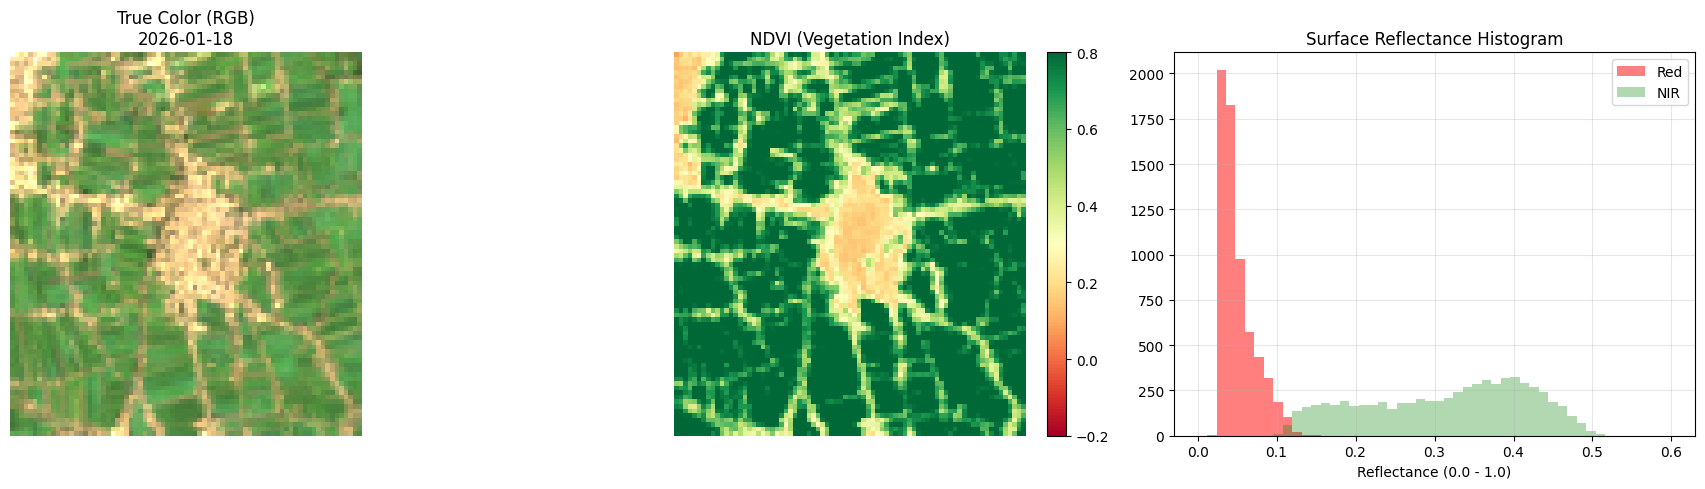

In [21]:
# A. Prepare RGB
# Brighten the image by normalizing based on the 98th percentile
rgb = np.dstack((red, green, blue))
p98 = np.nanpercentile(rgb, 98)
rgb_vis = np.clip(rgb / p98, 0, 1)

# B. Calculate NDVI
# (NIR - Red) / (NIR + Red)
ndvi = (nir - red) / (nir + red)

# C. Plotting
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: True Color
ax[0].imshow(rgb_vis)
ax[0].set_title(f"True Color (RGB)\n{selected_item.datetime.date()}")
ax[0].axis("off")

# Plot 2: NDVI
im = ax[1].imshow(ndvi, cmap="RdYlGn", vmin=-0.2, vmax=0.8)
ax[1].set_title("NDVI (Vegetation Index)")
ax[1].axis("off")
plt.colorbar(im, ax=ax[1], fraction=0.046, pad=0.04)

# Plot 3: Histogram
ax[2].hist(red.flatten(), bins=50, color="r", alpha=0.5, label="Red", range=(0, 0.6))
ax[2].hist(nir.flatten(), bins=50, color="green", alpha=0.3, label="NIR", range=(0, 0.6))
ax[2].set_title("Surface Reflectance Histogram")
ax[2].set_xlabel("Reflectance (0.0 - 1.0)")
ax[2].legend()
ax[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()